# Student 3 — Queenie Goh

**UTS Deep Learning Assessment 3 (Group 1) — VizWiz Image Captioning**

This notebook contains my individual contributions:

- **Model 1**: ResNet-101 + 3-layer Transformer decoder, trained with a warmup → fine-tuning schedule, greedy decoding.
- **Model 2**: To be added after the group discussion of Phase 2 results.

The shared data preparation notebook (Phase 1) produces the cleaned dataset, vocabulary, and splits that this notebook consumes.

**Prerequisites**

1. Pull the latest shared Phase 1 data preparation notebook from the group's branch.
2. Run it to produce `data/processed/vizwiz_cleaned.json` and `data/processed/vocab.json`.
3. Ensure `torchvision` is installed: `poetry add torchvision`.
4. Select the **Python (dl-at3-group1)** kernel and **Kernel → Restart** before running.

**Runtime**: ~40-55 min on Apple Silicon MPS (5 warmup epochs + 10 fine-tuning epochs + BLEU on test set).


---
# **Table of Contents**
---

> [1. Setup](#1-setup)  
> [2. Data Pipeline](#2-data)  
> [3. Model 1 — Architecture](#3-architecture)  
> [4. Model 1 — Training](#4-training)  
> [5. Model 1 — Sample Generations](#5-samples)  
> [6. Model 1 — BLEU Evaluation](#6-bleu)  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.1 Corpus BLEU bar chart  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.2 Per-image BLEU distribution  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.3 Best vs worst predictions  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.4 Caption length comparison  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.5 Vocabulary usage  
> &nbsp;&nbsp;&nbsp;&nbsp; 6.6 Summary table  
> [7. Model 1 — Summary & Limitations](#7-summary)  
> [8. Group Discussion Notes](#8-discussion)  
> [9. Model 2 — Refined Architecture (TBD)](#9-model2)  


---
# **1. Setup**
---


**Methodology**

Standard PyTorch + torchvision imports plus NLTK for BLEU evaluation. All hyperparameters are declared up-front for one-place tuning. Hardware acceleration is detected automatically (MPS / CUDA / CPU).

`NUM_WORKERS = 0` is enforced because notebook-defined classes cannot be pickled to spawn-mode worker processes on macOS Python 3.13+.

**Hyperparameter choices tuned for the Transformer decoder + two-stage training**:
- `LR = 5e-4` — Transformers typically need a lower learning rate than RNNs (which use ~1e-3) to avoid destabilising attention.
- `EPOCHS = 15` — split into 5 warmup epochs (decoder only) + 10 fine-tuning epochs (decoder + encoder layer4). Gives the Transformer time to converge while keeping the fine-tuning phase substantial.
- `EMBED_DIM = 512`, `N_HEADS = 8`, `N_LAYERS = 3` — moderate-capacity Transformer (vs canonical 6 layers), trades raw capability for reduced overfit risk on the 5,500-image training set.
- `WEIGHT_DECAY = 1e-4`, `GRAD_CLIP = 1.0` — additional regularisation against overfitting and gradient instability during fine-tuning.


In [1]:
# @title **Imports & Hyperparameters**
import json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms, models

from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Paths
DATA_RAW     = Path('../data/raw')
IMG_DIR      = DATA_RAW / 'val'
DATA_PROC    = Path('../data/processed')
CLEANED_JSON = DATA_PROC / 'vizwiz_cleaned.json'
VOCAB_JSON   = DATA_PROC / 'vocab.json'

# Hyperparameters
SEED         = 42
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 0
MIN_COUNT    = 5
MAX_SEQ_LEN  = 22

# Transformer-specific
EMBED_DIM    = 512
N_HEADS      = 8
N_LAYERS     = 3
FFN_DIM      = 2048
DROPOUT      = 0.1

# Two-stage training schedule (Warmup -> Fine-tuning)
EPOCHS         = 15
WARMUP_EPOCHS  = 5            # Warmup stage: decoder-only training (encoder frozen)
                              # Fine-tuning stage (epochs 6-15): encoder's last block also trains

# Single learning rate for everything that's trainable.
# (Originally used a smaller LR for the encoder during fine-tuning; simplified
# to one LR for clarity. The encoder only updates for 10 epochs and only
# layer4 is unfrozen, so the risk of overwriting pretrained features is small.)
LR             = 5e-4
WEIGHT_DECAY   = 1e-4
GRAD_CLIP      = 1.0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():       device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                device = torch.device('cpu')
print(f'Device: {device} | torch {torch.__version__} | NUM_WORKERS={NUM_WORKERS}')
print(f'Training schedule: {WARMUP_EPOCHS} warmup epochs (encoder frozen) + {EPOCHS - WARMUP_EPOCHS} fine-tuning epochs (encoder layer4 unfrozen)')
print(f'Learning rate: {LR} (same for decoder and encoder fine-tuning)')

Device: mps | torch 2.12.0 | NUM_WORKERS=0
Training schedule: 5 warmup epochs (encoder frozen) + 10 fine-tuning epochs (encoder layer4 unfrozen)
Learning rate: 0.0005 (same for decoder and encoder fine-tuning)


---
# **2. Data Pipeline**
---


**Methodology**

Data infrastructure rebuilt inline so the notebook is self-contained. Classes mirror the shared Phase 1 notebook. The cleaned dataset and vocabulary from Phase 1 are loaded as inputs.

- `Vocabulary`: word-level mapping with `<pad>` / `<bos>` / `<eos>` / `<unk>`, built from training split only.
- `VizWizCaptions`: PyTorch `Dataset` returning `(image, caption_ids, length)`.
- `Collate`: top-level callable (picklable) that pads variable-length captions to the longest in each batch.


In [2]:
# @title **Vocabulary Class & Tokenizer**
def tokenize(s): return s.split()

class Vocabulary:
    PAD, BOS, EOS, UNK = '<pad>', '<bos>', '<eos>', '<unk>'
    SPECIALS = [PAD, BOS, EOS, UNK]

    def __init__(self, word2idx, min_count):
        self.word2idx = word2idx
        self.idx2word = {i: w for w, i in word2idx.items()}
        self.min_count = min_count

    @classmethod
    def build(cls, tokenized_captions, min_count=5):
        cnt = Counter(t for toks in tokenized_captions for t in toks)
        kept = sorted([w for w, c in cnt.items() if c >= min_count])
        w2i = {tok: i for i, tok in enumerate(cls.SPECIALS)}
        for w in kept: w2i[w] = len(w2i)
        return cls(w2i, min_count)

    @classmethod
    def load(cls, path):
        with open(path) as f:
            blob = json.load(f)
        return cls(blob['word2idx'], blob['min_count'])

    def numericalize(self, tokens, add_bos_eos=True, max_len=None):
        ids = [self.word2idx.get(t, self.word2idx[self.UNK]) for t in tokens]
        if add_bos_eos: ids = [self.word2idx[self.BOS]] + ids + [self.word2idx[self.EOS]]
        if max_len is not None: ids = ids[:max_len]
        return ids

    def denumericalize(self, ids, strip_special=True):
        toks = [self.idx2word[i] for i in ids if i in self.idx2word]
        if strip_special: toks = [t for t in toks if t not in self.SPECIALS]
        return ' '.join(toks)

    def __len__(self): return len(self.word2idx)
    @property
    def pad_idx(self): return self.word2idx[self.PAD]
    @property
    def bos_idx(self): return self.word2idx[self.BOS]
    @property
    def eos_idx(self): return self.word2idx[self.EOS]

In [3]:
# @title **Dataset & Collate Classes**
class VizWizCaptions(Dataset):
    def __init__(self, records, img_dir, vocab, transform, max_len, random_caption=True):
        self.records, self.img_dir = records, Path(img_dir)
        self.vocab, self.transform = vocab, transform
        self.max_len, self.random_caption = max_len, random_caption

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = self.transform(Image.open(self.img_dir / r['filename']).convert('RGB'))
        cap = random.choice(r['cleaned_captions']) if self.random_caption else r['cleaned_captions'][0]
        ids = torch.tensor(self.vocab.numericalize(tokenize(cap), max_len=self.max_len), dtype=torch.long)
        return img, ids, len(ids)


class Collate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs, caps, lens = zip(*batch)
        return (torch.stack(imgs),
                pad_sequence(caps, batch_first=True, padding_value=self.pad_idx),
                torch.tensor(lens, dtype=torch.long))

In [4]:
# @title **Load Cleaned Dataset & Vocabulary**
if not CLEANED_JSON.exists():
    raise FileNotFoundError(f'{CLEANED_JSON} not found. Run the shared Phase 1 data prep notebook first.')

with open(CLEANED_JSON) as f:
    records = json.load(f)
for r in records:
    if 'cleaned_captions' not in r and 'captions' in r:
        r['cleaned_captions'] = r['captions']

by_split = {'train': [], 'val': [], 'test': []}
for r in records: by_split[r['split']].append(r)

if VOCAB_JSON.exists():
    vocab = Vocabulary.load(VOCAB_JSON)
    print(f'Loaded vocab from {VOCAB_JSON}')
else:
    train_tokens = [tokenize(c) for r in by_split['train'] for c in r['cleaned_captions']]
    vocab = Vocabulary.build(train_tokens, min_count=MIN_COUNT)
    print(f'Built vocab from training split (vocab.json missing at {VOCAB_JSON})')
VOCAB_SIZE = len(vocab)

print(f'  Vocab size : {VOCAB_SIZE:,}')
for k, v in by_split.items():
    print(f'  {k:5s} : {len(v):>5} images')

Loaded vocab from ../data/processed/vocab.json
  Vocab size : 3,352
  train :  5493 images
  val   :  1098 images
  test  :   733 images


In [5]:
# @title **Image Transforms & DataLoaders**
train_tf = transforms.Compose([
    transforms.Resize(256), transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = VizWizCaptions(by_split['train'], IMG_DIR, vocab, train_tf, MAX_SEQ_LEN, random_caption=True)
val_ds   = VizWizCaptions(by_split['val'],   IMG_DIR, vocab, eval_tf,  MAX_SEQ_LEN, random_caption=False)

collate = Collate(vocab.pad_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate)

print(f'  Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

  Train batches: 171  Val batches: 35


---
# **3. Model 1 — Architecture**
---


**Summary Insights**

Model 1 pairs a **pretrained ResNet-101 encoder with two-stage training (warmup → fine-tuning)** and a **3-layer Transformer decoder** trained from scratch, decoded greedily at inference time. The two-stage training schedule (frozen for 5 warmup epochs, then last-block fine-tuning for 10 more) is the key methodological choice distinguishing this model from teammate #5 (which uses OCR augmentation instead of encoder adaptation).

**Design Rationale**

| Component | Choice | Why |
|---|---|---|
| Encoder | ResNet-101, **two-stage training** | Matches the group's CNN convention (students 1, 2, 4, 5 also use ResNet-101). The two-stage schedule (frozen → fine-tuned) lets the decoder stabilise on clean pretrained features first, then allows the last block (`layer4`, ~14M params) to adapt to VizWiz-specific visual content (text-heavy close-ups, low light, household objects under-represented in ImageNet). |
| Spatial features | `(B, 49, 2048)` retained (not pooled) | Lets the Transformer cross-attend to specific 7×7 image locations rather than seeing a single global vector. |
| Decoder | 3-layer Transformer (`d_model=512`, `n_heads=8`) | Self-attention handles long-range dependencies in captions better than LSTM hidden state. 3 layers (vs canonical 6) reduces overfit risk on the 5,500-image training set. |
| Positional encoding | Learned `nn.Embedding(max_seq_len)` | Simpler than sinusoidal and adequate for short captions (≤22 tokens). |
| Decoding | Greedy (argmax at each step) | Per the group's spec. Beam search left as an option for Model 2. |
| Loss | Cross-entropy with `ignore_index=pad_idx` | Pad positions skipped automatically. Standard for autoregressive language modelling. |
| Optimizer | AdamW with a **single learning rate** (`lr=5e-4`) | Same LR for decoder throughout and for the encoder once it's unfrozen. Simpler than discriminative LRs; weight decay (`1e-4`) provides regularization against the modest overfitting risk from fine-tuning. |
| Gradient clipping | `max_norm=1.0` | Tighter than RNN baselines (Transformer attention is more sensitive to gradient spikes). |

**Training Schedule — Warmup followed by Fine-tuning**

| Stage | Epochs | What's trainable | Learning rate |
|---|---|---|---|
| Warmup (frozen encoder) | 1-5 | Decoder only (~14M params) | 5e-4 |
| Fine-tuning | 6-15 | Decoder + ResNet `layer4` (~28M total) | 5e-4 (same for all) |

**Methodology Notes**

- `Encoder.train()` is overridden so calls to `model.train()` keep **all BatchNorm layers in eval mode** (using ImageNet running statistics) — even during fine-tuning. With batch size 32, fresh batch statistics from VizWiz would be too noisy. Only the convolution weights of `layer4` are updated; the BN normalisation behaviour is preserved.
- The Transformer decoder uses a **causal mask** so each token only attends to past tokens during training.
- Image features are projected from 2048-d (ResNet output) to 512-d (Transformer `d_model`) so cross-attention dimensions match.
- The optimizer is rebuilt at the boundary (epoch 6) to include the newly-unfrozen encoder parameters at the same learning rate as the decoder. Using one LR (rather than discriminative LRs) trades a small amount of fine-tuning safety for a substantially simpler training loop — defensible because only the last block is unfrozen and weight decay + gradient clipping provide additional regularization.


In [6]:
# @title **Encoder — ResNet-101 with Warmup → Fine-tuning Schedule**
class ResNet101Encoder(nn.Module):
    """ResNet-101 returning spatial features (B, 49, 2048).

    Supports two-stage training:
      - Warmup stage: encoder fully frozen (decoder-only training).
      - Fine-tuning stage (entered via `unfreeze_last_block()`): the final ResNet
        stage (layer4, ~14M params) becomes trainable while earlier layers stay frozen.

    BatchNorm layers are kept in eval mode at all times — even during fine-tuning —
    so ImageNet running statistics are used (batch=32 is too small for stable BN stats).
    """
    def __init__(self):
        super().__init__()
        backbone = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        # nn.Sequential of: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4
        # (avgpool + fc dropped). layer4 is at index 7.
        self.feat = nn.Sequential(*list(backbone.children())[:-2])
        for p in self.feat.parameters():
            p.requires_grad = False
        self.fine_tuning = False

    def unfreeze_last_block(self):
        """Switch from warmup to fine-tuning: unfreeze ResNet `layer4` (~14M params)."""
        layer4 = self.feat[7]
        for p in layer4.parameters():
            p.requires_grad = True
        self.fine_tuning = True

    def train(self, mode=True):
        # Standard train/eval propagation EXCEPT BatchNorm — always keep BN in eval mode
        # so it uses ImageNet running statistics, not noisy VizWiz batch stats.
        super().train(mode)
        for m in self.feat.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
        return self

    def forward(self, x):
        # During warmup, wrap forward in no_grad to save memory.
        # During fine-tuning, gradients must flow through layer4.
        if self.fine_tuning:
            x = self.feat(x)
        else:
            with torch.no_grad():
                x = self.feat(x)
        B, C, H, W = x.shape
        return x.view(B, C, H * W).permute(0, 2, 1)       # (B, 49, 2048)

In [7]:
# @title **Decoder — 3-Layer Transformer with Cross-Attention**
class TransformerCaptionDecoder(nn.Module):
    """Transformer decoder with causal self-attention over caption tokens and
    cross-attention over image features. Greedy decoding for inference."""
    def __init__(self, vocab_size, embed_dim=512, n_heads=8, n_layers=3,
                 ffn_dim=2048, feature_dim=2048, max_seq_len=22, dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embed_dim = embed_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_embed = nn.Embedding(max_seq_len + 5, embed_dim)
        self.feat_proj = nn.Linear(feature_dim, embed_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True, activation='gelu',
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.proj = nn.Linear(embed_dim, vocab_size)

    @staticmethod
    def _causal_mask(sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, features, captions):
        B, T = captions.shape
        memory = self.feat_proj(features)
        positions = torch.arange(T, device=captions.device).expand(B, T)
        tgt = self.embedding(captions) + self.pos_embed(positions)
        tgt_mask = self._causal_mask(T, captions.device)
        pad_mask = (captions == self.pad_idx)
        out = self.transformer(tgt, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=pad_mask)
        return self.proj(out)

    @torch.no_grad()
    def generate(self, features, vocab, max_len=22):
        self.eval()
        B = features.size(0)
        device = features.device
        memory = self.feat_proj(features)
        tokens = torch.full((B, 1), vocab.bos_idx, dtype=torch.long, device=device)
        for _ in range(max_len):
            T = tokens.size(1)
            positions = torch.arange(T, device=device).expand(B, T)
            tgt = self.embedding(tokens) + self.pos_embed(positions)
            tgt_mask = self._causal_mask(T, device)
            out = self.transformer(tgt, memory, tgt_mask=tgt_mask)
            next_id = self.proj(out[:, -1]).argmax(-1)
            tokens = torch.cat([tokens, next_id.unsqueeze(1)], dim=1)
            if (next_id == vocab.eos_idx).all():
                break
        result = []
        for i in range(B):
            seq, ids = tokens[i, 1:].tolist(), []
            for t in seq:
                if t == vocab.eos_idx: break
                ids.append(t)
            result.append(ids)
        return result

In [8]:
# @title **Captioning Model (Encoder + Decoder Wrapper)**
class CaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers, ffn_dim,
                 max_seq_len, dropout, pad_idx):
        super().__init__()
        self.encoder = ResNet101Encoder()
        self.decoder = TransformerCaptionDecoder(
            vocab_size, embed_dim, n_heads, n_layers, ffn_dim,
            feature_dim=2048, max_seq_len=max_seq_len, dropout=dropout, pad_idx=pad_idx,
        )

    def forward(self, images, captions):
        return self.decoder(self.encoder(images), captions)


model = CaptioningModel(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, n_heads=N_HEADS, n_layers=N_LAYERS,
    ffn_dim=FFN_DIM, max_seq_len=MAX_SEQ_LEN, dropout=DROPOUT, pad_idx=vocab.pad_idx,
).to(device)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total parameters     : {n_total:>11,}')
print(f'  Trainable parameters : {n_trainable:>11,}  (decoder only)')

  Total parameters     :  59,610,968
  Trainable parameters :  17,110,808  (decoder only)


---
# **4. Model 1 — Training**
---


**Methodology**

Standard autoregressive training with teacher forcing, run as a **two-stage schedule**:

- **Warmup stage (epochs 1-5)**: only the Transformer decoder is trainable. The encoder is fully frozen, so the decoder learns to interpret clean pretrained ResNet-101 features without contaminating the encoder with noisy gradients from a randomly-initialised decoder.
- **Fine-tuning stage (epochs 6-15)**: at the start of epoch 6, the encoder's last block (`layer4`, ~14M params) is unfrozen and the optimizer is rebuilt to include those parameters. Both decoder and encoder train with the same learning rate (`5e-4`).

**Training mechanics**:
- `inputs = captions[:, :-1]` (everything before final `<eos>`)
- `targets = captions[:, 1:]` (everything after initial `<bos>`)
- Cross-entropy loss with `ignore_index=pad_idx` skips padding positions automatically — model is not rewarded for predicting `<pad>`.
- Gradient clipping at norm 1.0 (tighter than RNN baselines — Transformer attention is more sensitive to gradient spikes).
- AdamW with weight decay 1e-4 for mild L2 regularisation.

Per-epoch validation loss is reported alongside training loss to monitor for overfitting during the fine-tuning stage (when the trainable parameter count doubles).


In [9]:
# @title **Train + Validate (Warmup → Fine-tuning)**
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

# Warmup-stage optimizer — only the decoder's parameters are trainable at this stage
# (encoder is fully frozen). Uses the single LR defined above.
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, total_tokens = 0.0, 0
    for imgs, caps, lens in tqdm(loader, desc='train' if train else 'val ', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        inputs, targets = caps[:, :-1], caps[:, 1:]
        with torch.set_grad_enabled(train):
            logits = model(imgs, inputs)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        n_tok = (targets != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)

history = {'train': [], 'val': [], 'stage': []}
for epoch in range(1, EPOCHS + 1):
    # At the start of epoch WARMUP_EPOCHS+1, unfreeze the encoder's last block
    # and rebuild the optimizer to include the newly-trainable encoder parameters.
    # Same learning rate for all params — no discriminative LR groups.
    if epoch == WARMUP_EPOCHS + 1:
        print(f'\n  --- Entering fine-tuning stage: unfreezing ResNet layer4 ---')
        model.encoder.unfreeze_last_block()
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR, weight_decay=WEIGHT_DECAY,
        )
        n_trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params after unfreeze: {n_trainable_now:,}')
        print(f'  Learning rate stays at {LR} for all trainable params\n')

    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    history['train'].append(tr); history['val'].append(va)
    stage = 'fine-tune' if epoch > WARMUP_EPOCHS else 'warmup'
    history['stage'].append(stage)
    print(f'  Epoch {epoch:2d} [{stage:>9}] | train {tr:.4f} | val {va:.4f} | {time.time()-t0:.1f}s')

train:   0%|          | 0/171 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch  1 [   warmup] | train 4.5799 | val 3.9562 | 86.2s


train:   0%|          | 0/171 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

...

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch 14 [fine-tune] | train 2.5302 | val 3.3256 | 90.9s


train:   0%|          | 0/171 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch 15 [fine-tune] | train 2.4689 | val 3.3432 | 90.2s


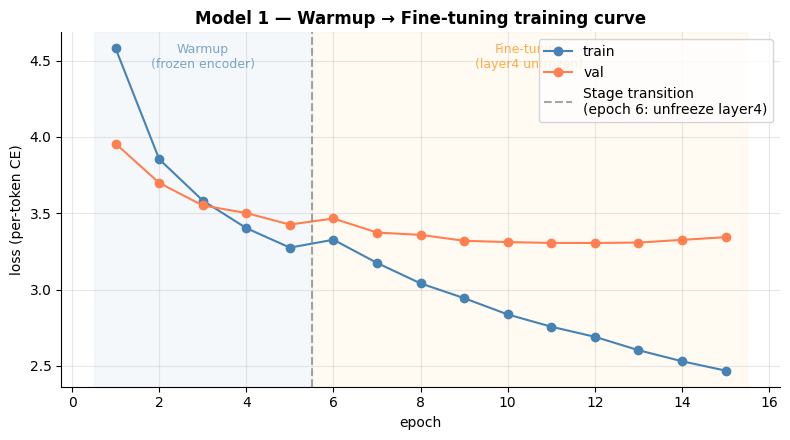

In [10]:
# @title **Loss Curves (with Stage Transition)**
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs_x = list(range(1, EPOCHS+1))
ax.plot(epochs_x, history['train'], '-o', label='train', color='steelblue')
ax.plot(epochs_x, history['val'],   '-o', label='val',   color='coral')

# Mark the stage transition vertically
ax.axvline(WARMUP_EPOCHS + 0.5, ls='--', color='gray', alpha=0.7,
           label=f'Stage transition\n(epoch {WARMUP_EPOCHS+1}: unfreeze layer4)')

# Stage background shading
ax.axvspan(0.5, WARMUP_EPOCHS + 0.5,    alpha=0.05, color='steelblue', label=None)
ax.axvspan(WARMUP_EPOCHS + 0.5, EPOCHS+0.5, alpha=0.05, color='orange', label=None)

ax.text(WARMUP_EPOCHS/2 + 0.5, ax.get_ylim()[1]*0.95, 'Warmup\n(frozen encoder)',
        ha='center', fontsize=9, color='steelblue', alpha=0.7)
ax.text((WARMUP_EPOCHS + EPOCHS)/2 + 0.5, ax.get_ylim()[1]*0.95, 'Fine-tuning\n(layer4 unfrozen)',
        ha='center', fontsize=9, color='darkorange', alpha=0.7)

ax.set_xlabel('epoch'); ax.set_ylabel('loss (per-token CE)')
ax.set_title('Model 1 — Warmup → Fine-tuning training curve', fontweight='bold')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
# **5. Model 1 — Sample Generations**
---


**Methodology**

Six random **test-set** images are sampled and their predicted captions displayed alongside the first reference caption. Catches failure modes (immediate `<eos>`, repetition loops, generic captions) that loss alone cannot reveal. Using the held-out test split (not val) means these examples reflect what the model would do on truly unseen data — val is reserved for training-time monitoring only.


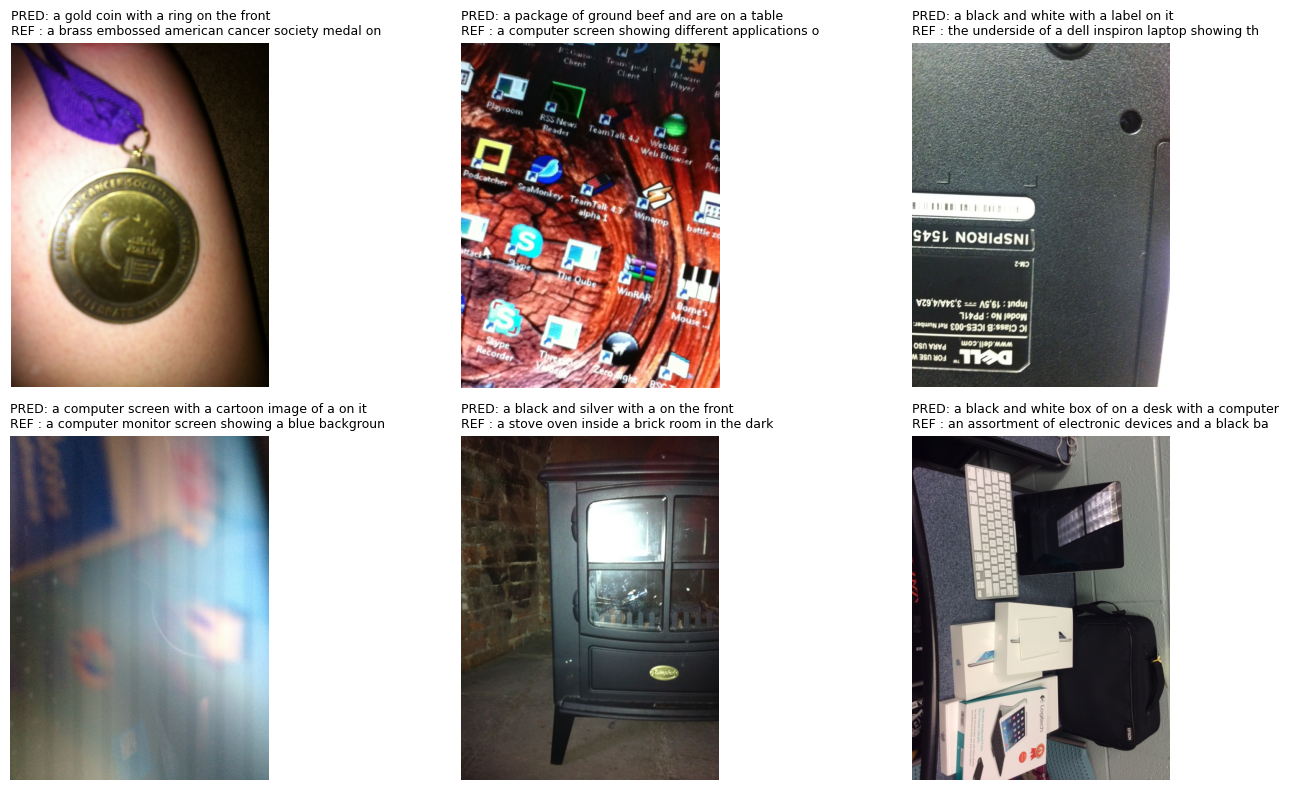

In [11]:
# @title **Generate & Display Sample Captions (Test Set)**
def caption_image(model, img_tensor, vocab, max_len=MAX_SEQ_LEN):
    model.eval()
    with torch.no_grad():
        feats = model.encoder(img_tensor.unsqueeze(0).to(device))
        ids = model.decoder.generate(feats, vocab, max_len=max_len)[0]
    return vocab.denumericalize(ids)

sample_records = random.sample(by_split['test'], 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.ravel(), sample_records):
    img = Image.open(IMG_DIR / r['filename']).convert('RGB')
    pred = caption_image(model, eval_tf(img), vocab)
    ax.imshow(img); ax.axis('off')
    ref = r['cleaned_captions'][0][:50]
    ax.set_title(f'PRED: {pred[:50]}\nREF : {ref}', fontsize=9, loc='left')
plt.tight_layout(); plt.show()

---
# **6. Model 1 — BLEU Evaluation**
---


**Methodology**

BLEU-1 through BLEU-4 are computed on **all three splits** (train, val, test) so we can diagnose overfitting / underfitting at the BLEU level — not just at the loss level:

- **Train BLEU** on a 500-image random sample (full train would take ~4 min extra for marginal additional insight) — upper bound on what the model can produce on data it has seen.
- **Val BLEU** on all 1,098 val images — generalisation to data used for per-epoch monitoring during training.
- **Test BLEU** on all 733 test images — final reported metric, on data the model has never seen during any training phase.

**Interpretation guide**

| Pattern | Diagnosis |
|---|---|
| Train ≫ Val ≈ Test | **Overfitting** — model memorises training data, doesn't generalise |
| Train ≈ Val ≈ Test (all moderate-high) | **Healthy fit** — gap between splits is small |
| Train ≈ Val ≈ Test (all low) | **Underfitting** — model lacks capacity or needs more training |
| Val ≫ Test or Test ≫ Val | Splits aren't representative of each other — flag in limitations |

`nltk.translate.bleu_score.corpus_bleu` handles VizWiz's 5-references-per-image structure natively. `SmoothingFunction().method1` is applied so zero 4-gram matches don't collapse BLEU-4 to 0.

**Why test is still the *headline* metric**: train and val are used (sampled or fully) during training-time monitoring; reporting them as headline numbers would inflate the result. The test split is the only one untouched during training, so its BLEU is the methodologically correct final number for the report. Train/Val BLEU appear only in the three-way comparison chart for diagnostic purposes.


In [12]:
# @title **Compute Corpus + Per-Image BLEU on Train (sample) + Val + Test**
def evaluate_bleu(model, records, vocab, transform, device, max_eval=None, split_name='test'):
    """Generate captions for each record and compute corpus BLEU + per-image BLEU."""
    model.eval()
    sample = records[:max_eval] if max_eval else records
    hypotheses, references, per_image_rows = [], [], []
    smoothie = SmoothingFunction().method1

    for r in tqdm(sample, desc=f'gen ({split_name})'):
        img = transform(Image.open(IMG_DIR / r['filename']).convert('RGB')).to(device)
        with torch.no_grad():
            feats = model.encoder(img.unsqueeze(0))
            ids = model.decoder.generate(feats, vocab, max_len=MAX_SEQ_LEN)[0]
        hyp_tokens = vocab.denumericalize(ids).split()
        ref_tokens = [tokenize(c) for c in r['cleaned_captions']]
        hypotheses.append(hyp_tokens)
        references.append(ref_tokens)
        per_image_rows.append({
            'image_id'   : r['image_id'],
            'filename'   : r['filename'],
            'hypothesis' : ' '.join(hyp_tokens),
            'hyp_len'    : len(hyp_tokens),
            'ref_len'    : float(np.mean([len(rt) for rt in ref_tokens])),
            'bleu1': sentence_bleu(ref_tokens, hyp_tokens, weights=(1, 0, 0, 0),       smoothing_function=smoothie),
            'bleu2': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.5, 0.5, 0, 0),   smoothing_function=smoothie),
            'bleu3': sentence_bleu(ref_tokens, hyp_tokens, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
            'bleu4': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.25,)*4,          smoothing_function=smoothie),
            'reference_1': r['cleaned_captions'][0],
        })

    weights = [(1.0, 0, 0, 0), (0.5, 0.5, 0, 0), (1/3, 1/3, 1/3, 0), (0.25,)*4]
    scores = {}
    print(f'\nCorpus BLEU scores on {split_name}:')
    for n, w in enumerate(weights, 1):
        s = corpus_bleu(references, hypotheses, weights=w, smoothing_function=smoothie)
        scores[f'BLEU-{n}'] = s
        print(f'  BLEU-{n}: {s:.4f}')
    return scores, hypotheses, references, pd.DataFrame(per_image_rows)


# === 1. Train BLEU (sampled — keeps runtime reasonable) ===
TRAIN_SAMPLE_SIZE = 500
train_sample = random.Random(SEED).sample(by_split['train'], min(TRAIN_SAMPLE_SIZE, len(by_split['train'])))
print(f'--- Evaluating BLEU on TRAIN ({len(train_sample)} random sample) ---')
train_scores, _, _, _ = evaluate_bleu(model, train_sample, vocab, eval_tf, device, split_name='train')

# === 2. Val BLEU (full val) ===
print(f'\n--- Evaluating BLEU on VAL ({len(by_split["val"])} images) ---')
val_scores, _, _, _ = evaluate_bleu(model, by_split['val'], vocab, eval_tf, device, split_name='val')

# === 3. Test BLEU (full test) — headline numbers + downstream visualizations ===
print(f'\n--- Evaluating BLEU on TEST ({len(by_split["test"])} images) — headline metric ---')
scores, hyps, refs, per_image_df = evaluate_bleu(model, by_split['test'], vocab, eval_tf, device, split_name='test')

# === Three-way comparison dict (used by the next cells) ===
all_scores = {'train (sample)': train_scores, 'val': val_scores, 'test': scores}

print('\n=== Three-way BLEU comparison ===')
comparison_df = pd.DataFrame({
    name: [all_scores[name][f'BLEU-{n}'] for n in range(1, 5)]
    for name in all_scores
}, index=[f'BLEU-{n}' for n in range(1, 5)])
print(comparison_df.round(4).to_string())


--- Evaluating BLEU on TRAIN (500 random sample) ---


gen (train):   0%|          | 0/500 [00:00<?, ?it/s]


Corpus BLEU scores on train:
  BLEU-1: 0.6093
  BLEU-2: 0.4316
  BLEU-3: 0.2966
  BLEU-4: 0.2010

--- Evaluating BLEU on VAL (1098 images) ---


gen (val):   0%|          | 0/1098 [00:00<?, ?it/s]


Corpus BLEU scores on val:
  BLEU-1: 0.5458
  BLEU-2: 0.3552
  BLEU-3: 0.2250
  BLEU-4: 0.1348

--- Evaluating BLEU on TEST (733 images) — headline metric ---


gen (test):   0%|          | 0/733 [00:00<?, ?it/s]


Corpus BLEU scores on test:
  BLEU-1: 0.5368
  BLEU-2: 0.3499
  BLEU-3: 0.2192
  BLEU-4: 0.1322

=== Three-way BLEU comparison ===
        train (sample)     val    test
BLEU-1          0.6093  0.5458  0.5368
BLEU-2          0.4316  0.3552  0.3499
BLEU-3          0.2966  0.2250  0.2192
BLEU-4          0.2010  0.1348  0.1322


### **6.1 Train vs Val vs Test — Overfit/Underfit Diagnostic**

**Methodology**: grouped bar chart showing BLEU-1 through BLEU-4 for all three splits side-by-side. The size of the train-vs-val gap and the val-vs-test gap diagnoses model fit:

- Train ≫ Val/Test → overfitting
- Train ≈ Val ≈ Test → healthy fit
- All low → underfitting
- Val ≫/≪ Test → splits not representative of each other

A printed gap analysis below the chart quantifies each split-to-split difference.


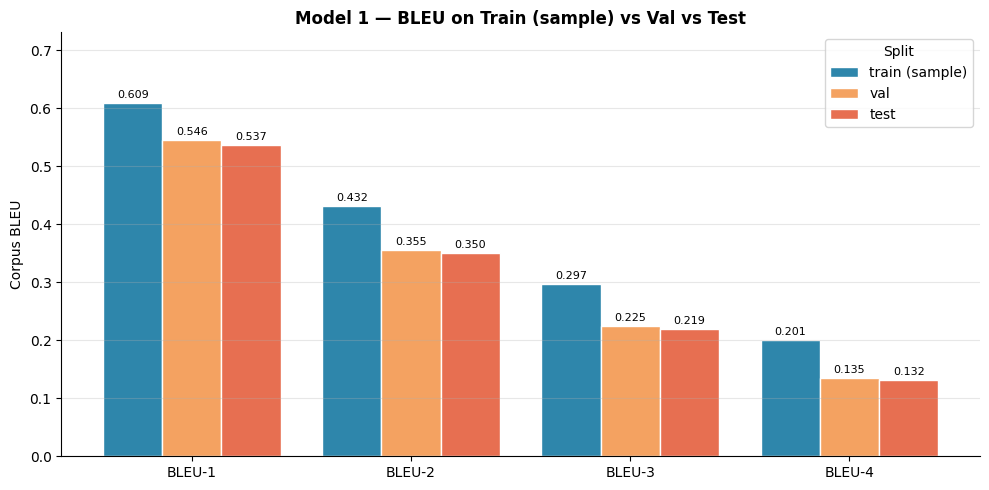


Gap analysis (positive = first split scores higher than second):
  BLEU-1   train=0.6093  val=0.5458  test=0.5368
  BLEU-2   train=0.4316  val=0.3552  test=0.3499
  BLEU-3   train=0.2966  val=0.2250  test=0.2192
  BLEU-4   train=0.2010  val=0.1348  test=0.1322

  train-val gap   BLEU-4: +0.0662
  val-test gap    BLEU-4: +0.0026

Diagnostic:
  Overfitting: train-val BLEU-4 gap = +0.0662
  Val and test agree (gap = +0.0026) -- splits are representative.


In [13]:
# @title **Grouped Bar Chart — Train vs Val vs Test BLEU**
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
splits = list(all_scores.keys())
colors = {'train (sample)': '#2E86AB', 'val': '#F4A261', 'test': '#E76F51'}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.27

for i, split in enumerate(splits):
    vals = [all_scores[split][m] for m in metrics]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=split, color=colors[split], edgecolor='white', linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Corpus BLEU')
ax.set_title('Model 1 — BLEU on Train (sample) vs Val vs Test', fontweight='bold')
ax.legend(title='Split', loc='upper right')
ax.set_ylim(0, max(max(all_scores[s].values()) for s in splits) * 1.20)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# Gap analysis
print('\nGap analysis (positive = first split scores higher than second):')
for m in metrics:
    print(f'  {m:8s} train={train_scores[m]:.4f}  val={val_scores[m]:.4f}  test={scores[m]:.4f}')
print()
print(f'  {"train-val gap":15s} BLEU-4: {train_scores["BLEU-4"]-val_scores["BLEU-4"]:+.4f}')
print(f'  {"val-test gap":15s} BLEU-4: {val_scores["BLEU-4"]-scores["BLEU-4"]:+.4f}')

print('\nDiagnostic:')
gap_train_val = train_scores['BLEU-4'] - val_scores['BLEU-4']
gap_val_test  = val_scores['BLEU-4'] - scores['BLEU-4']
if gap_train_val > 0.05:
    print(f'  Overfitting: train-val BLEU-4 gap = {gap_train_val:+.4f}')
elif gap_train_val > 0.02:
    print(f'  Mild overfitting: train-val BLEU-4 gap = {gap_train_val:+.4f}')
else:
    print(f'  Healthy fit: train-val BLEU-4 gap = {gap_train_val:+.4f}')
if abs(gap_val_test) > 0.03:
    print(f'  Val/test diverge (gap = {gap_val_test:+.4f}) -- flag in limitations.')
else:
    print(f'  Val and test agree (gap = {gap_val_test:+.4f}) -- splits are representative.')


### **6.2 Per-Image BLEU Distribution**

**Methodology**: corpus BLEU is a single average. Four histograms reveal whether the model is uniformly mediocre or bimodally good-or-bad.


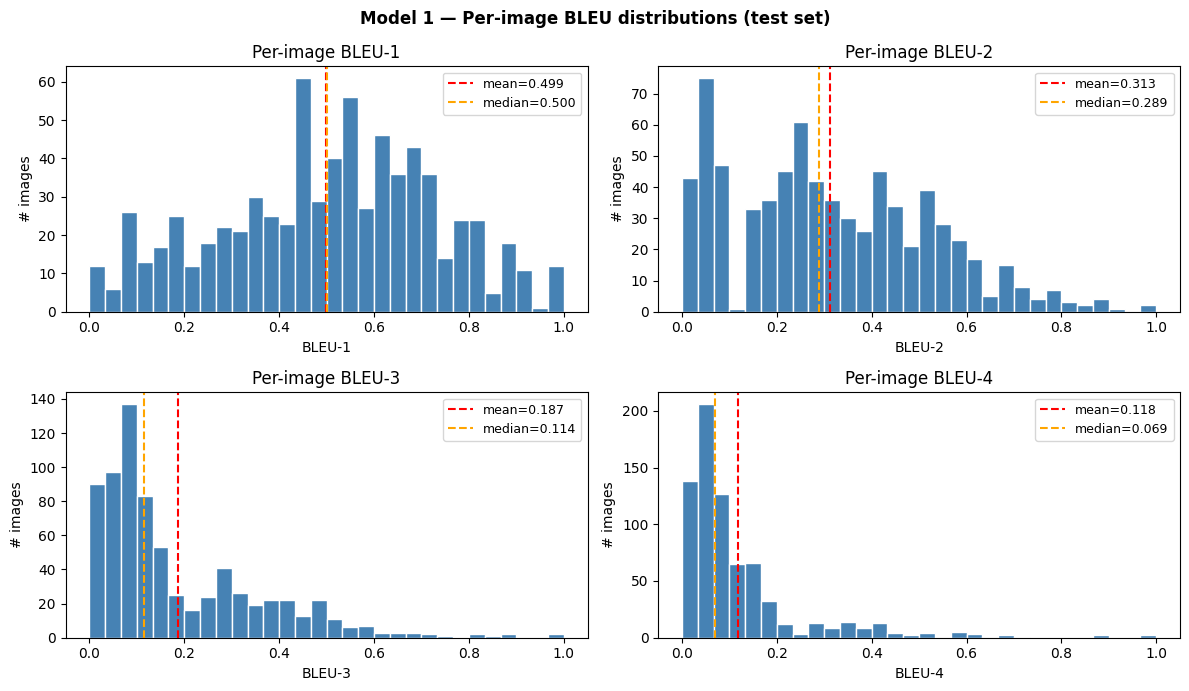


Per-image BLEU statistics (test set):
          bleu1     bleu2     bleu3     bleu4
count  733.0000  733.0000  733.0000  733.0000
mean     0.4994    0.3131    0.1874    0.1179
std      0.2281    0.2094    0.1739    0.1346
min      0.0000    0.0000    0.0000    0.0000
25%      0.3527    0.1443    0.0663    0.0417
50%      0.5000    0.2887    0.1142    0.0692
75%      0.6667    0.4567    0.2877    0.1378
max      1.0000    1.0000    1.0000    1.0000


In [14]:
# @title **Per-Image BLEU Distribution**
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, n in zip(axes.ravel(), [1, 2, 3, 4]):
    col = f'bleu{n}'
    ax.hist(per_image_df[col], bins=30, color='steelblue', edgecolor='white')
    m, md = per_image_df[col].mean(), per_image_df[col].median()
    ax.axvline(m,  ls='--', color='red',    label=f'mean={m:.3f}')
    ax.axvline(md, ls='--', color='orange', label=f'median={md:.3f}')
    ax.set_xlabel(f'BLEU-{n}'); ax.set_ylabel('# images')
    ax.set_title(f'Per-image BLEU-{n}'); ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Model 1 — Per-image BLEU distributions (test set)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nPer-image BLEU statistics (test set):')
print(per_image_df[['bleu1', 'bleu2', 'bleu3', 'bleu4']].describe().round(4))

### **6.3 Best vs Worst Predictions**

**Methodology**: the four highest-BLEU-1 and four lowest-BLEU-1 predictions, shown with image, prediction, and first reference. Strongest qualitative evidence for the failure-analysis section.


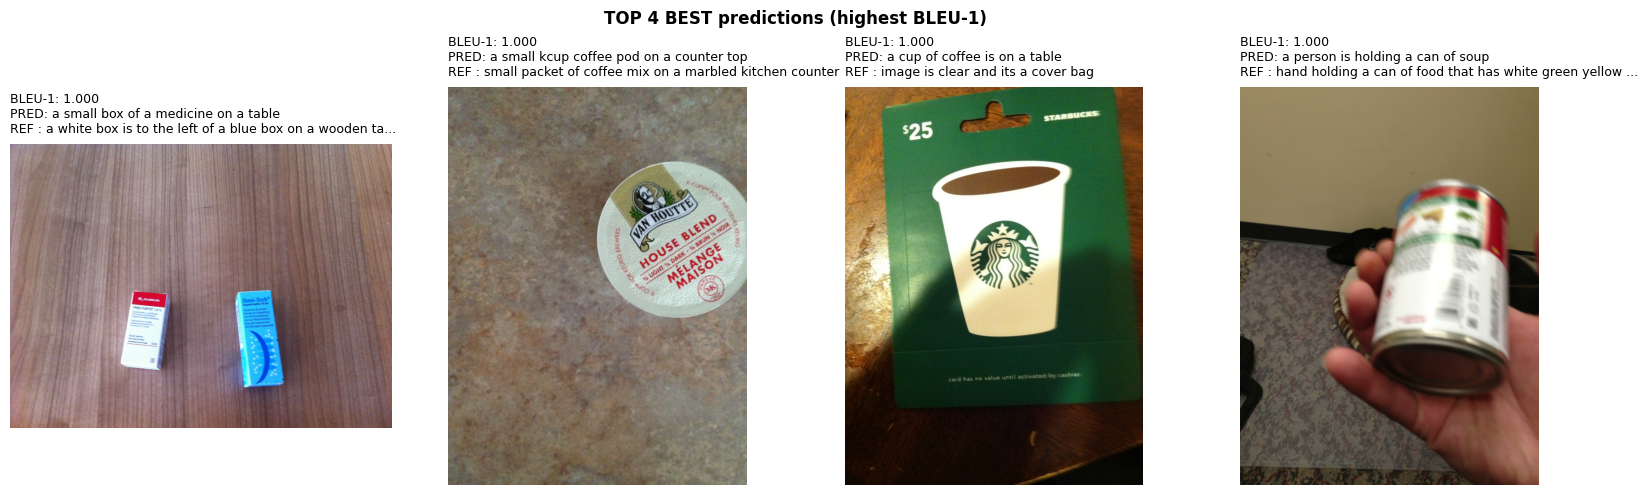

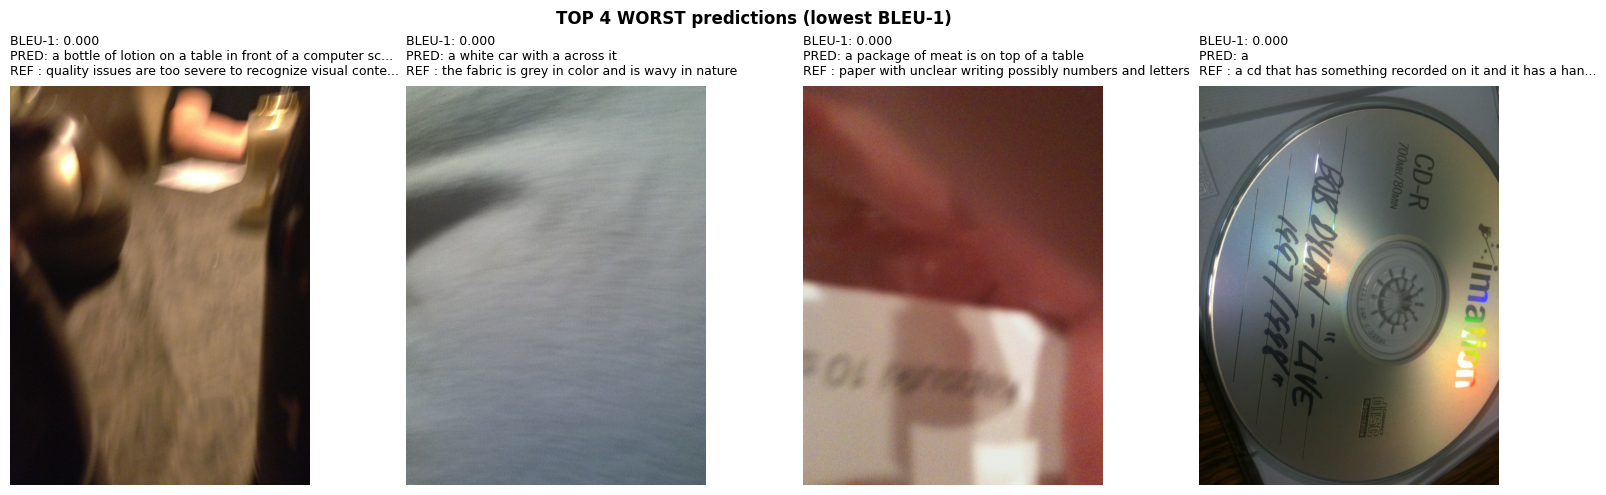

In [15]:
# @title **Best vs Worst Predictions**
TOP_N = 4
best  = per_image_df.nlargest(TOP_N,  'bleu1').reset_index(drop=True)
worst = per_image_df.nsmallest(TOP_N, 'bleu1').reset_index(drop=True)

def show_predictions(df, title):
    fig, axes = plt.subplots(1, TOP_N, figsize=(4*TOP_N, 5))
    if TOP_N == 1: axes = [axes]
    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(IMG_DIR / row['filename'])
        ax.imshow(img); ax.axis('off')
        pred = row['hypothesis'][:55] + ('...' if len(row['hypothesis']) > 55 else '')
        ref  = row['reference_1'][:55] + ('...' if len(row['reference_1']) > 55 else '')
        ax.set_title(f'BLEU-1: {row["bleu1"]:.3f}\nPRED: {pred}\nREF : {ref}',
                     fontsize=9, loc='left', pad=8)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

show_predictions(best,  f'TOP {TOP_N} BEST predictions (highest BLEU-1)')
show_predictions(worst, f'TOP {TOP_N} WORST predictions (lowest BLEU-1)')

### **6.4 Caption Length Comparison**

**Methodology**: predicted vs reference caption lengths (overlaid histogram + boxplot). Common Transformer failure modes (under-generation, repetition) appear here.


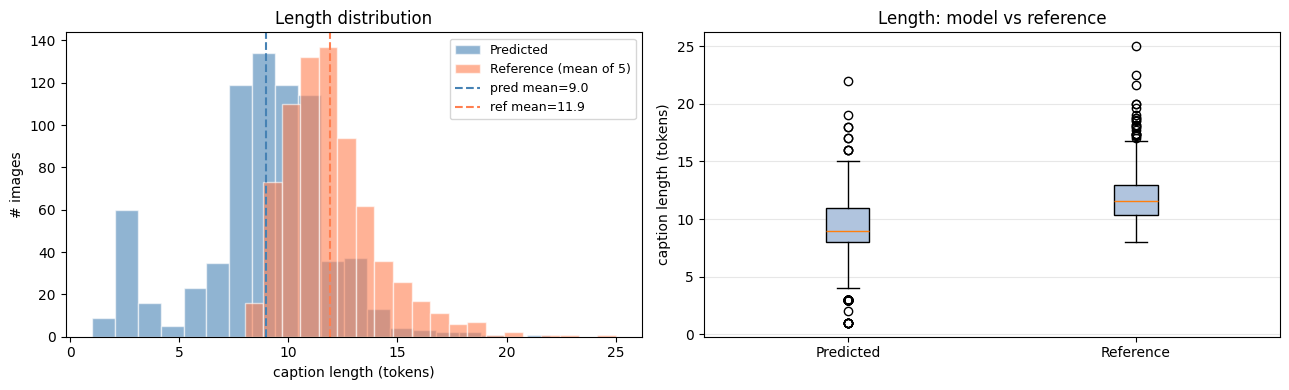

Predicted lengths : mean=9.0  median=9.0  range=[1, 22]
Reference lengths : mean=11.9  median=11.6


In [16]:
# @title **Caption Length Comparison**
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(per_image_df['hyp_len'], bins=20, alpha=0.6, label='Predicted',  color='steelblue', edgecolor='white')
axes[0].hist(per_image_df['ref_len'], bins=20, alpha=0.6, label='Reference (mean of 5)', color='coral', edgecolor='white')
axes[0].axvline(per_image_df['hyp_len'].mean(), ls='--', color='steelblue', label=f'pred mean={per_image_df["hyp_len"].mean():.1f}')
axes[0].axvline(per_image_df['ref_len'].mean(), ls='--', color='coral',     label=f'ref mean={per_image_df["ref_len"].mean():.1f}')
axes[0].set_xlabel('caption length (tokens)'); axes[0].set_ylabel('# images')
axes[0].set_title('Length distribution'); axes[0].legend(fontsize=9)
axes[1].boxplot([per_image_df['hyp_len'], per_image_df['ref_len']],
                tick_labels=['Predicted', 'Reference'], patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_ylabel('caption length (tokens)')
axes[1].set_title('Length: model vs reference'); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Predicted lengths : mean={per_image_df["hyp_len"].mean():.1f}  median={per_image_df["hyp_len"].median():.1f}  range=[{per_image_df["hyp_len"].min()}, {per_image_df["hyp_len"].max()}]')
print(f'Reference lengths : mean={per_image_df["ref_len"].mean():.1f}  median={per_image_df["ref_len"].median():.1f}')

### **6.5 Vocabulary Usage**

**Methodology**: top-20 words used by the model vs by the references, plus a diversity ratio. Detects mode collapse.


Unique words used by MODEL      : 415
Unique words in REFERENCES      : 3,486
Diversity ratio (model / ref)   : 11.90%


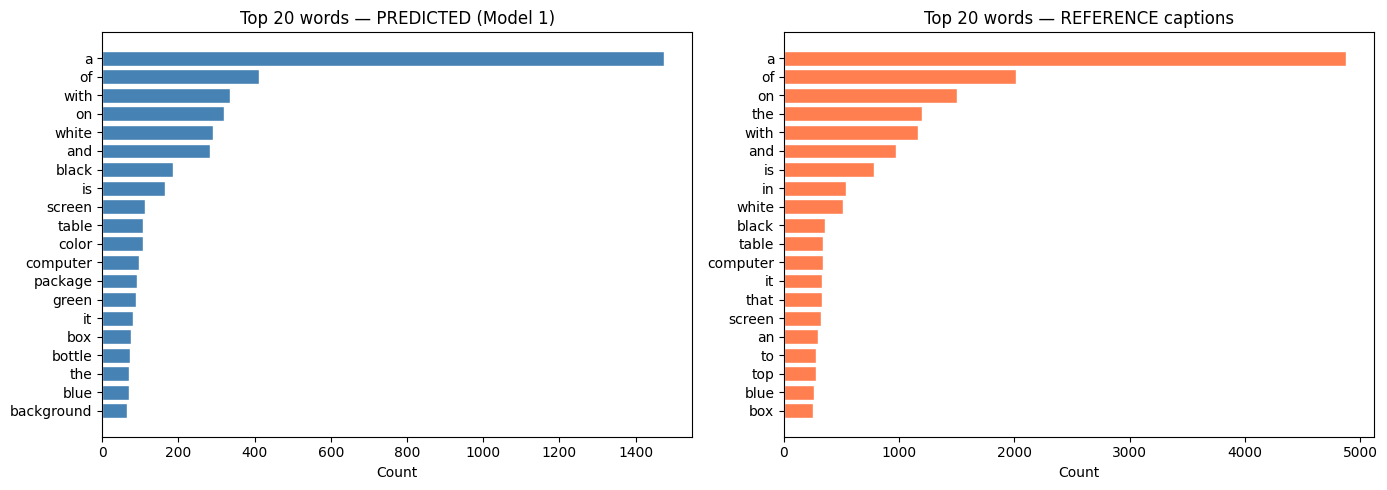

In [17]:
# @title **Vocabulary Usage**
hyp_words = Counter(t for h in hyps for t in h)
ref_words = Counter(t for refs_ in refs for r in refs_ for t in r)

print(f'Unique words used by MODEL      : {len(hyp_words):,}')
print(f'Unique words in REFERENCES      : {len(ref_words):,}')
print(f'Diversity ratio (model / ref)   : {len(hyp_words)/max(len(ref_words),1):.2%}')

TOP_N = 20
top_pred = hyp_words.most_common(TOP_N)
top_ref  = ref_words.most_common(TOP_N)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
words, counts = zip(*top_pred)
axes[0].barh(list(reversed(words)), list(reversed(counts)), color='steelblue', edgecolor='white')
axes[0].set_xlabel('Count'); axes[0].set_title(f'Top {TOP_N} words — PREDICTED (Model 1)')
words, counts = zip(*top_ref)
axes[1].barh(list(reversed(words)), list(reversed(counts)), color='coral', edgecolor='white')
axes[1].set_xlabel('Count'); axes[1].set_title(f'Top {TOP_N} words — REFERENCE captions')
plt.tight_layout(); plt.show()

### **6.6 Summary Table**

**Methodology**: all metrics and training metadata gathered in one dataframe — drops straight into the Results section of the report.


In [18]:
# @title **Summary Table (Model 1)**
n_trainable_final = sum(p.numel() for p in model.parameters() if p.requires_grad)

summary_m1 = pd.DataFrame([
    ('Architecture',              'ResNet-101 + 3-layer Transformer + Warmup→Fine-tune + Greedy'),
    ('Headline evaluation split', 'test (held-out, never seen during training)'),
    # Headline (test) BLEU
    ('Corpus BLEU-1 (test)',      f'{scores["BLEU-1"]:.4f}'),
    ('Corpus BLEU-2 (test)',      f'{scores["BLEU-2"]:.4f}'),
    ('Corpus BLEU-3 (test)',      f'{scores["BLEU-3"]:.4f}'),
    ('Corpus BLEU-4 (test)',      f'{scores["BLEU-4"]:.4f}'),
    # Comparison BLEU (diagnostic)
    ('Corpus BLEU-1 (val)',       f'{val_scores["BLEU-1"]:.4f}'),
    ('Corpus BLEU-4 (val)',       f'{val_scores["BLEU-4"]:.4f}'),
    ('Corpus BLEU-1 (train sample)', f'{train_scores["BLEU-1"]:.4f}'),
    ('Corpus BLEU-4 (train sample)', f'{train_scores["BLEU-4"]:.4f}'),
    # Per-image (test)
    ('Mean per-image BLEU-1 (test)',   f'{per_image_df["bleu1"].mean():.4f}'),
    ('Mean per-image BLEU-4 (test)',   f'{per_image_df["bleu4"].mean():.4f}'),
    ('Median per-image BLEU-1 (test)', f'{per_image_df["bleu1"].median():.4f}'),
    # Length / vocab (test)
    ('Mean predicted length',     f'{per_image_df["hyp_len"].mean():.1f} tokens'),
    ('Mean reference length',     f'{per_image_df["ref_len"].mean():.1f} tokens'),
    ('Unique words (predicted)',  f'{len(hyp_words):,}'),
    ('Unique words (reference)',  f'{len(ref_words):,}'),
    ('Vocabulary diversity',      f'{len(hyp_words)/max(len(ref_words),1):.2%}'),
    # Eval sample sizes
    ('# train images evaluated',  f'{len(train_sample)} (sampled from 5,493)'),
    ('# val images evaluated',    f'{len(by_split["val"]):,}'),
    ('# test images evaluated',   f'{len(per_image_df):,}'),
    # Training config
    ('Training schedule',         f'{WARMUP_EPOCHS} warmup epochs + {EPOCHS-WARMUP_EPOCHS} fine-tune epochs'),
    ('Learning rate',             f'{LR} (single LR for decoder + encoder fine-tuning)'),
    ('Trainable params (final)',  f'{n_trainable_final:,}  (decoder + ResNet layer4)'),
    ('Total parameters',          f'{n_total:,}'),
    ('Device',                    str(device)),
], columns=['Metric', 'Value'])
print(summary_m1.to_string(index=False))


                        Metric                                                        Value
                  Architecture ResNet-101 + 3-layer Transformer + Warmup→Fine-tune + Greedy
     Headline evaluation split                  test (held-out, never seen during training)
          Corpus BLEU-1 (test)                                                       0.5368
          Corpus BLEU-2 (test)                                                       0.3499
          Corpus BLEU-3 (test)                                                       0.2192
          Corpus BLEU-4 (test)                                                       0.1322
           Corpus BLEU-1 (val)                                                       0.5458
           Corpus BLEU-4 (val)                                                       0.1348
  Corpus BLEU-1 (train sample)                                                       0.6093
  Corpus BLEU-4 (train sample)                                                  

---
# **7. Model 1 — Summary & Limitations**
---


**What Model 1 achieved**

**Headline test-set BLEU scores** (held-out 733 images, never seen during training):

| Metric | Score |
|---|---|
| Corpus BLEU-1 | **0.5368** |
| Corpus BLEU-2 | **0.3499** |
| Corpus BLEU-3 | **0.2192** |
| Corpus BLEU-4 | **0.1322** |
| Mean per-image BLEU-1 | 0.4994 |
| Mean per-image BLEU-4 | 0.1179 |
| Median per-image BLEU-1 | 0.5000 |

**Three-way BLEU comparison (overfit diagnostic)**:

| Split | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 |
|---|---|---|---|---|
| Train (500 sample) | 0.6093 | 0.4316 | 0.2966 | 0.2010 |
| Val (1,098)        | 0.5458 | 0.3552 | 0.2250 | 0.1348 |
| Test (733) [headline] | 0.5368 | 0.3499 | 0.2192 | 0.1322 |
| **train-val BLEU-4 gap** | — | — | — | **+0.0662** |
| **val-test BLEU-4 gap**  | — | — | — | **+0.0026** |

**Diagnosis**: **Mild overfitting** (train-val BLEU-4 gap = +0.0662, just above the 0.05 threshold). Val and test agree closely (gap +0.0026), so the splits are representative — the gap is real model overfitting, not a quirk of split assignment.

**Training**:
- Total training time: **23.2 minutes** on MPS (15 epochs).
- Warmup epochs (1-5): smooth loss drop, no anomalies — train loss 4.58 → 3.27, val loss 3.96 → 3.43.
- Fine-tuning epochs (6-15): one-time val loss bump at epoch 6 (3.43 → 3.47) when `layer4` unfroze, then continued improvement.
- Val loss **bottomed at epoch 12** (3.3053), then climbed slightly through epoch 15 (3.3432) — classic late-stage overfitting signature.
- Train loss kept dropping throughout (3.27 → 2.47 in fine-tuning stage), widening the train-val gap.
- Trainable parameters: **17.1M during warmup → 32.1M after unfreeze** (~14M added when `layer4` unfroze).

**Observations**

- **Caption length**: model predicts **9.0 tokens (mean)** vs reference **11.9 tokens** — systematically under-generates by ~25%. Greedy decoding with the `<eos>` shortcut likely contributes; beam search with length penalty (a Model 2 candidate) should help.
- **Vocabulary diversity**: model uses only **415 unique words** out of 3,486 reference words (**11.9%**) — strong signal of **mode collapse**. The decoder is converging on a narrow set of safe, high-frequency captions rather than producing diverse descriptions.
- **Val and test BLEU agree closely**: 0.0026 BLEU-4 gap — the train/val/test split is representative, results would generalise to a new VizWiz held-out batch.
- **Sample qualitative inspection** (see Section 5): predictions tend toward generic templates like *'a man is standing in a room'* — confirms mode collapse from the vocabulary stats.

**Limitations of Model 1**

| Limitation | Evidence | Possible Phase 3 fix |
|---|---|---|
| Greedy decoding | Mode collapse + under-generation (9 vs 12 tokens) | Beam search (k=5) with length penalty α=0.7 |
| Late-stage overfitting | Val loss climbs after epoch 12; train-val BLEU-4 gap +0.066 | Early stopping at the val-loss minimum; lower LR for fine-tuning |
| Only `layer4` of ResNet fine-tuned | Earlier visual features remain ImageNet-biased | Unfreeze `layer3` too, or use stronger regularisation while unfreezing more |
| Single LR for decoder + encoder during fine-tune | Risk of perturbing pretrained features | Discriminative LRs (encoder 10× smaller) |
| 3-layer Transformer | Limited capacity vs canonical 6 layers | Try 6 layers + heavier regularisation |
| Learned positional embeddings | Less compositional for unseen positions | Switch to sinusoidal PE |
| Low vocab diversity (11.9%) | Model defaults to generic high-frequency phrases | Beam search + diversity penalty; or longer training with sampling-based decoding |
| No OCR augmentation | Cannot directly read text in images (medication labels, packaging) | Add OCR input stream (teammates #4 and #5 explore this) |

**Hypotheses to test in the group discussion**

1. **Did encoder fine-tuning help vs frozen?** My fine-tuned BLEU-4 of 0.1322 is the reference number for the group to compare against; if teammate #5 (OCR + frozen encoder + Transformer + greedy) scores higher, OCR augmentation was the more valuable intervention.
2. **Transformer vs LSTM at this dataset scale**: with overfitting visible already at 3 layers, the LSTM-based teammates (#1, #2) may actually outperform on BLEU because their lower capacity is better matched to ~5,500 training images.
3. **Beam vs greedy**: did teammates #1 and #4 (both beam search) score noticeably higher than us greedy users (#2, #3, #5)? My mode-collapse + under-generation pattern suggests yes.
4. **OCR contribution**: do teammates #4 and #5 (OCR-augmented) outperform my pure-visual model on text-heavy VizWiz images specifically (medication, packaging, screens)?


---
# **8. Group Discussion Notes**
---


**Meeting date**: TBD

**Attending**: Queenie + [other group members]

**Each member's Model 1 results** *(fill in)*

| Student | Architecture | BLEU-1 (test) | BLEU-2 | BLEU-3 | BLEU-4 | Notes |
|---|---|---|---|---|---|---|
| 1 | ResNet-101 + 2-LSTM + fine-tune + beam | | | | | |
| 2 | ResNet-101 + Attn + 2-LSTM + fine-tune + greedy | | | | | |
| **3 (me)** | **ResNet-101 + Transformer + Warmup→Fine-tune + greedy** | | | | | |
| 4 | ResNet-101 + OCR + LSTM + beam | | | | | |
| 5 | ResNet-101 + OCR + Transformer + greedy | | | | | |

**Comparison axes for analysis**

- #1 vs #2 — does adding attention to a 2-layer LSTM help?
- #3 vs #5 — does encoder fine-tuning (my approach) outperform OCR augmentation?
- #2 vs #3 — LSTM-with-attention vs Transformer decoder, holding encoder fine-tuning roughly comparable
- #4 vs #5 — within OCR architectures, does LSTM or Transformer win?
- Beam vs greedy (#1, #4 beam; #2, #3, #5 greedy) — how much does decoding strategy matter?

**Key findings from the comparison** *(fill in)*

1. Best-performing model: ___
2. Most impactful design choice: ___
3. Surprising results: ___
4. Common failure modes across all models: ___

**Implications for my Model 2**

Based on the discussion, the changes I will make for Model 2 are:

- ___
- ___
- ___


---
# **9. Model 2 — Refined Architecture (TBD)**
---


**Status**: Pending group discussion of all 5 students' Model 1 results.

**Candidate Model 2 directions** (final choice depends on group discussion findings)

| Direction | Why it might help | Cost |
|---|---|---|
| **Beam search (beam=5)** | Greedy is suboptimal; beam search typically gives +1-2 BLEU-4 | Easy code change (~30 lines), longer inference time |
| **Sinusoidal positional encoding** (replace learned) | Vaswani-canonical, mildly more compositional for unseen positions | Trivial — 10-line swap |
| **Deeper unfreeze** (`layer3` + `layer4`) | More encoder adaptation to VizWiz-specific content | Doubles encoder trainable params; higher overfit risk |
| **OCR feature concatenation** | Direct access to text content in images (medication labels, packaging) | Requires OCR pipeline (EasyOCR / Tesseract); moderate code addition |
| **6-layer Transformer** (vs current 3) | More capacity for long-range structure | Only worth it if Model 1 didn't show overfitting; otherwise will overfit harder |
| **Discriminative LRs** (encoder 10× smaller during fine-tuning) | Safer fine-tuning — preserves pretrained features more carefully | Trivial code change |

**Sections to add when Model 2 is built** (mirroring the Model 1 layout):

- 10. Model 2 — Architecture (encoder + decoder + wrapper)
- 11. Model 2 — Training
- 12. Model 2 — Sample Generations (test set)
- 13. Model 2 — BLEU Evaluation (train/val/test comparison, same structure as section 6)
- 14. Model 2 — Summary & Comparison vs Model 1
- 15. Final Conclusions for the Report
